In [19]:
%load_ext autoreload
%autoreload 2

from word_play.environment import Environment_State, Environment_Properties, Entity_State, Entity_Properties, Environment, Action_Selection
from environments.altar.simple_altar.env import Simple_Altar_Env
from environments.altar.simple_altar.entities import Altar, Altar_Properties
from environments.altar.simple_altar.agents import Random_Harvest_Agent, Explicit_Belief_Harvest_Agent, Constant_Harvest_Agent
from environments.altar.simple_altar.reward_func import altar_reward_func
from environments.altar.simple_altar.actions import Harvest_Bananas_Sanction_Apples
from word_play.presets.model_presets import Human, ChatGPT
from word_play.presets.movement_system_presets import Single_Point_Position, SINGLE_POINT_MOVEMENT_SYSTEM

from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define run function

In [2]:
def run_sim(env: Environment, step_count: int):

	action_history = []
	reward_history = []
	observation_history = []
	expectation_history = []
	cot_history = []
	new_expectation_prompt_history = []
	cot_prompt_history = []

	for step in tqdm(range(step_count)):
		this_rounds_actions = []
		this_round_rewards = []
		this_round_observations = []
		this_round_expectations = []
		this_round_cot_history = []
		this_round_new_expectation_prompt_history = []
		this_round_cot_prompt_history = []

		for agent_id, agent in enumerate(env.agents):
			observation, last_reward, termination, truncation, info = env.last(agent_id)
			# can also use: observation = env.observe(agent_id)
			action, info = agent.select_action(observation)
			this_rounds_actions.append(action)

			# recording logging information (this could be done by a logger)
			this_round_observations.append(observation)
			if info and 'new_expectations' in info:
				this_round_expectations.append((agent_id, info['new_expectations']))
			if info and 'selection_CoT' in info:
				this_round_cot_history.append((agent_id, info['selection_CoT']))
			if info and 'new_expectation_prompt' in info:
				this_round_new_expectation_prompt_history.append((agent_id, info['new_expectation_prompt']))
			if info and 'CoT_prompt' in info:
				this_round_cot_prompt_history.append((agent_id, info['CoT_prompt']))
		
		env.step(this_rounds_actions)

		# we need to perform actions to see the resulting rewards
		for agent_id, agent in enumerate(env.agents):
			observation, last_reward, termination, truncation, info = env.last(agent_id)
			this_round_rewards.append(last_reward)
		
		# recording logging information (this could be done by a logger)
		action_history.append(this_rounds_actions)
		reward_history.append(this_round_rewards)
		observation_history.append(this_round_observations)
		expectation_history.append(this_round_expectations)
		cot_history.append(this_round_cot_history)
		new_expectation_prompt_history.append(this_round_new_expectation_prompt_history)
		cot_prompt_history.append(this_round_cot_prompt_history)

	return action_history, reward_history, observation_history, expectation_history, cot_history, new_expectation_prompt_history, cot_prompt_history

# Set environment variables

In [3]:
GPT3_MODEL_NAME = 'gpt-3.5-turbo-0125'
GPT3_MODEL_PARAMS = {
	'temperature': 1,
	'top_p': 0.1,
}

ENVIRONMENT_DESCRIPTION = """Game Title: Altar Harvest

Objective: To accumulate the highest number of points over several rounds by strategically harvesting and sanctioning different fruits.

Gameplay: Players can imagine themselves being farmers within neighbouring nations. The game is played as a series of rounds. In each round, all players independently select a fruit to harvest and a fruit to sanction. At the end of each round reward/points are given based on the interactions between the resources chosen to be harvested and sanctions. There also exist altars which give information to players."""

# GPT can cooperate with/exploit static agent

In [28]:
constant_agent = Constant_Harvest_Agent(
	state=Entity_State(
		position=Single_Point_Position()
	),
	properties=Entity_Properties(
		name='Alice'
	),
	constant_action=Harvest_Bananas_Sanction_Apples(),
	constant_action_target='self'
)
explicit_belief_agent = Explicit_Belief_Harvest_Agent(
	state=Entity_State(
		position=Single_Point_Position()
	),
	properties=Entity_Properties(
		name='explicit belief agent'
	),
	#model=Human(),
	model=ChatGPT(
		model_name=GPT3_MODEL_NAME,
		system_prompt='You are a game playing agent.',
		#model_params=GPT3_MODEL_PARAMS,
		verbosity=2
	),
	env_description=ENVIRONMENT_DESCRIPTION,
	history_length=-1
)

env = Simple_Altar_Env(
	state=Environment_State(
		entities=[constant_agent, explicit_belief_agent]
	),
	properties=Environment_Properties(
		description=ENVIRONMENT_DESCRIPTION
	),
	movement_system=SINGLE_POINT_MOVEMENT_SYSTEM,
	reward_func=altar_reward_func
	#reward_func=zero_reward_func
)

action_history, reward_history, observation_history, expectation_history, cot_history, new_expectation_prompt_history, cot_prompt_history = run_sim(env=env, step_count=10)

  0%|          | 0/10 [00:00<?, ?it/s]

generating text...
generating text...


 10%|█         | 1/10 [00:12<01:56, 12.96s/it]

generating text...
generating text...


 20%|██        | 2/10 [00:24<01:36, 12.07s/it]

...

 80%|████████  | 8/10 [01:57<00:31, 15.67s/it]

generating text...
generating text...


 90%|█████████ | 9/10 [02:11<00:15, 15.02s/it]

generating text...
generating text...


100%|██████████| 10/10 [02:25<00:00, 14.59s/it]


In [29]:
for step, actions in enumerate(action_history):
	print(f'Step {step} actions:')
	for player_idx, action in enumerate(actions):
		print(f'Player {player_idx} selected action: {action}')

Step 0 actions:
Player 0 selected action: Harvest bananas and sanction apples.
Player 1 selected action: Harvest bananas and sanction nothing.
Step 1 actions:
Player 0 selected action: Harvest bananas and sanction apples.
Player 1 selected action: Harvest bananas and sanction bananas.
Step 2 actions:
Player 0 selected action: Harvest bananas and sanction apples.
Player 1 selected action: Harvest apples and sanction bananas.
Step 3 actions:
Player 0 selected action: Harvest bananas and sanction apples.
Player 1 selected action: Harvest apples and sanction nothing.
Step 4 actions:
Player 0 selected action: Harvest bananas and sanction apples.
Player 1 selected action: Harvest apples and sanction nothing.
Step 5 actions:
Player 0 selected action: Harvest bananas and sanction apples.
Player 1 selected action: Harvest apples and sanction nothing.
Step 6 actions:
Player 0 selected action: Harvest bananas and sanction apples.
Player 1 selected action: Harvest bananas and sanction bananas.
Ste

In [30]:
player_idx = 1
for step, observations in enumerate(observation_history):
	print(f'\n\n============================== Step {step} ==============================\n\n')
	print(observations[player_idx])



============================== Step 0 ==============================


Altar Signals:

Previous Player Actions:
No Previous Actions

My Reward: None

Possible Actions:
[0]: Harvest apples and sanction bananas.
[1]: Harvest apples and sanction apples.
[2]: Harvest apples and sanction nothing.
[3]: Harvest bananas and sanction bananas.
[4]: Harvest bananas and sanction apples.
[5]: Harvest bananas and sanction nothing.


============================== Step 1 ==============================


Altar Signals:

Previous Player Actions:
Alice: Harvest bananas and sanction apples.

My Reward: 10

Possible Actions:
[0]: Harvest apples and sanction bananas.
[1]: Harvest apples and sanction apples.
[2]: Harvest apples and sanction nothing.
[3]: Harvest bananas and sanction bananas.
[4]: Harvest bananas and sanction apples.
[5]: Harvest bananas and sanction nothing.


============================== Step 2 ==============================


Altar Signals:

Previous Player Actions:
Alice: Harvest ban

In [31]:
player_idx = 1
for step, cots in enumerate(cot_history):
	print(f'\n\n============================== Step {step} ==============================\n\n')
	print(cots[0][1])



============================== Step 0 ==============================


My thought process for selecting this round's action involves a combination of strategic analysis and risk assessment based on the initial round's outcomes and potential interactions between different fruits.

Considering the outcomes from the first round, where Alice and I both chose not to take any actions and received no rewards, I need to adapt my strategy for this round to aim for a positive outcome while also considering the possible moves other players might make.

Given that the outcome for this round is dependent on both the fruit I choose to harvest and the fruit I choose to sanction, I need to carefully assess the potential risks and rewards associated with each action combination:

1. If I choose to harvest apples and sanction bananas, I might benefit if apples are valuable this round and if sanctioning bananas does not backfire on me. However, there is a risk that other players may target apple harves

In [32]:
player_idx = 1
for step, prompts in enumerate(cot_prompt_history):
	print(f'\n\n============================== Step {step} ==============================\n\n')
	print(prompts[0][1])



============================== Step 0 ==============================


# Game Description:
Game Title: Altar Harvest

Objective: To accumulate the highest number of points over several rounds by strategically harvesting and sanctioning different fruits.

Gameplay: Players can imagine themselves being farmers within neighbouring nations. The game is played as a series of rounds. In each round, all players independently select a fruit to harvest and a fruit to sanction. At the end of each round reward/points are given based on the interactions between the resources chosen to be harvested and sanctions. There also exist altars which give information to players.

# History:
## Round 0:
### Actions:
Alice: None
Me: None
### My Reward: None

# Expectations:
I expect that other players will strategize based on the initial round's outcomes and the potential benefits and consequences of harvesting and sanctioning different fruits. Given the competitive nature of the game and the goal to accum

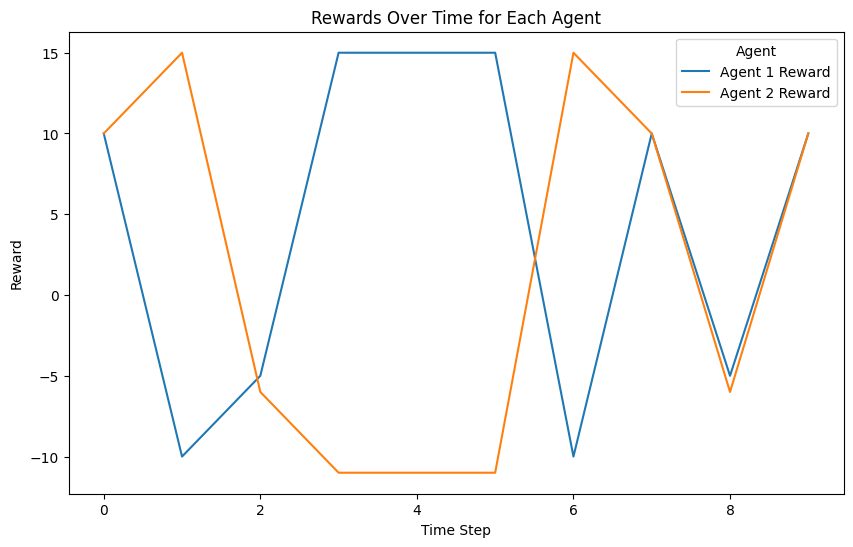

In [33]:
# Convert reward_history to a pandas DataFrame
df = pd.DataFrame(reward_history, columns=['Agent 1 Reward', 'Agent 2 Reward'])
df['Time Step'] = df.index

# Melting the DataFrame for use with Seaborn
df_melted = df.melt(id_vars=['Time Step'], var_name='Agent', value_name='Reward')

# Plotting with Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='Time Step', y='Reward', hue='Agent')
plt.title('Rewards Over Time for Each Agent')
plt.xlabel('Time Step')
plt.ylabel('Reward')
plt.legend(title='Agent')
plt.show()

In [ ]:
banana_altar = Altar(
	state=Entity_State(
		position=Single_Point_Position()
	),
	properties=Altar_Properties(
		name='Banana Altar',
		signal='Eat bananas!'
	)
)
apple_altar = Altar(
	state=Entity_State(
		position=Single_Point_Position()
	),
	properties=Altar_Properties(
		name='Apple Altar',
		signal='Eat apples!'
	)
)